# Exploration Plotting
Plots exploration behaviour (number of actions explored per turn) across nomenclatures, domains, and models.
Load data by running `data_processing.ipynb` first.

## Setup

In [1]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
os.chdir("../..")

## Lookup Maps and Style Constants

In [3]:
rewards_per_scale = {
    'high_scale':     [75, 50, 25],
    'low_scale':      [0.75, 0.5, 0.25],
    'high_neg_scale': [-25, -50, -75],
    'low_neg_scale':  [-0.25, -0.5, -0.75],
}

STYLE_CONSTANTS = {
    'max_val': {
        'linestyle': '--',
        'color': 'black',
        'label': 'Maximum',
    },
    'min_val': {
        'linestyle': '--',
        'color': 'firebrick',
        'label': 'Minimum',
    },
    'high_neg_scale': {
        'linestyle': '-',
        'color': 'crimson',
        'label': 'Negative High',
        'marker': '^',
    },
    'low_neg_scale': {
        'linestyle': '-',
        'color': 'salmon',
        'label': 'Negative Low',
        'marker': 'v',
    },
    'high_scale': {
        'linestyle': '-',
        'color': 'darkgreen',
        'label': 'Positive High',
        'marker': '^',
    },
    'low_scale': {
        'linestyle': '-',
        'color': 'palegreen',
        'label': 'Positive Low',
        'marker': 'v',
    },
}

nomenclature_map = {
    'alphanumeric':     'Alphanumeric',
    'ordinal_helpful':  'Ordinal - Helpful',
    'ordinal_mislead':  'Ordinal - Misleading',
    'world_helpful':    'World - Helpful',
    'world_mislead':    'World - Misleading',
    'sent_new_helpful': 'Sentiment - Helpful',
    'sent_new_mislead': 'Sentiment - Misleading',
}

metric_map = {
    'cum_regret':       'Scaled Cum. Regret',
    'exploration_count': 'States Explored',
}

## Configuration

In [4]:
# Load merged results from data_processing.ipynb output
results_df = pd.read_csv('experiments/merged_sem_var_results.csv')
print(f"Loaded {len(results_df)} rows")
results_df[['domain', 'model', 'history', 'variance']].value_counts().reset_index(name='count')

Loaded 1274 rows


,domain,model,history,variance,count
0,Farm,Qwen3-14B,Summarized,Low,36
1,Farm,Llama3-8B,Summarized,No,36
2,Farm,Qwen3-32B,Summarized,No,36
3,Farm,Qwen3-32B,Summarized,Low,36
4,Farm,Qwen3-32B,Summarized,High,36
5,Farm,Llama3-8B,Summarized,High,36
6,Farm,Qwen3-14B,Summarized,No,36
7,Farm,Llama3-8B,Summarized,Low,36
8,Farm,Qwen3-14B,Summarized,High,36
9,Clothing Recommendation,Llama3-8B,Summarized,No,29


In [5]:
# Metrics to plot
metrics = ['cum_regret', 'exploration_count']

# Nomenclatures to show as columns (sent_new_* replaces old sent_*)
nomenclatures = [
    'alphanumeric',
    'ordinal_helpful', 'ordinal_mislead',
    'world_helpful',   'world_mislead',
    'sent_new_helpful', 'sent_new_mislead',
]

# Preferred domain row order (any not in this list are appended at the end)
domain_order = ['Farm', 'Bandit', 'Clothing Recommendation']

# Filter parameters — plots are generated for every model in the data
hist     = 'Summarized'
variance = 'No'

legend_order = ['max_val', 'min_val', 'high_scale', 'high_neg_scale', 'low_scale', 'low_neg_scale']

## Plotting

One figure per model, one row per domain, one column per nomenclature.

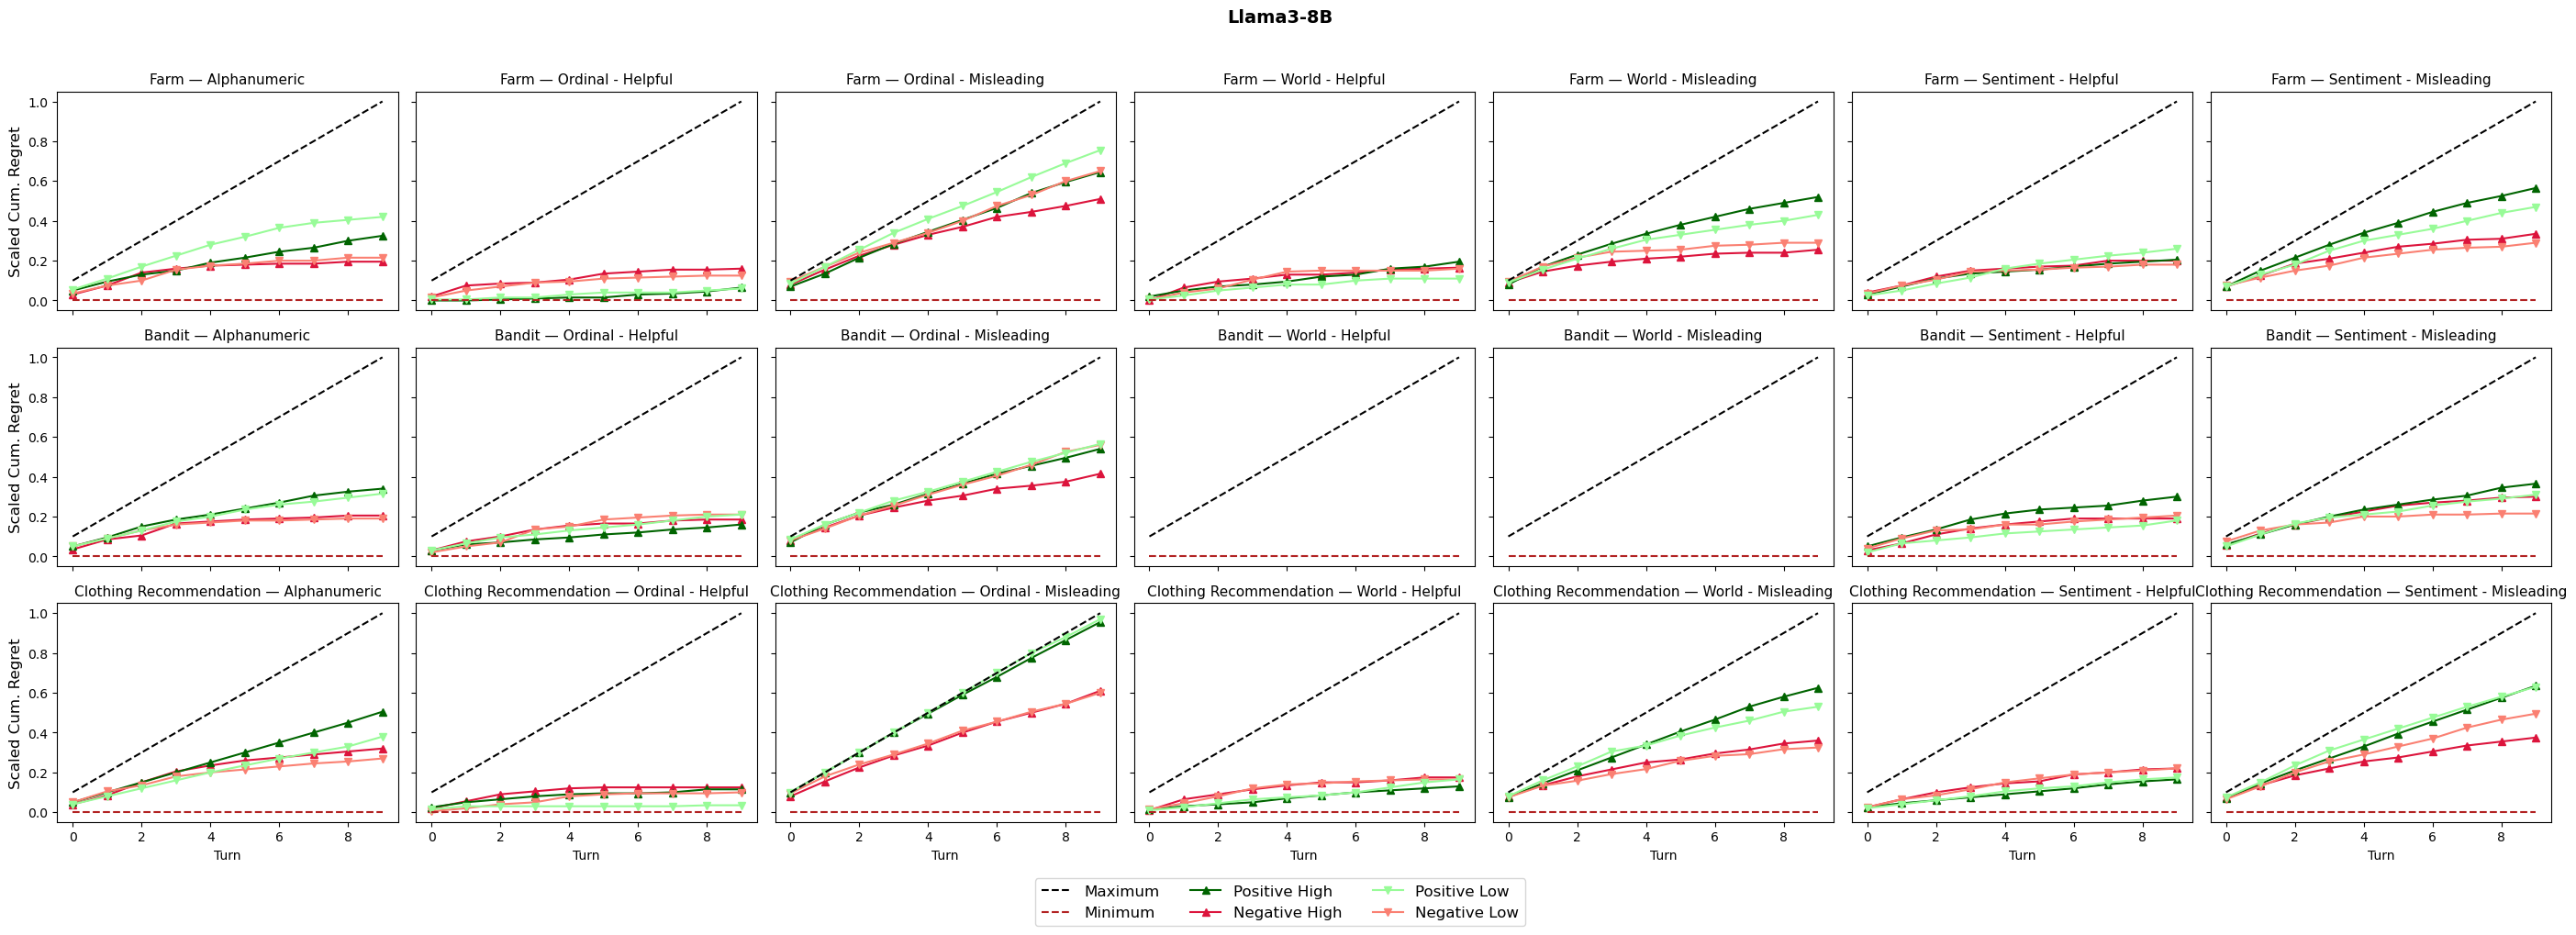

Saved figures for model=Llama3-8B, metric=cum_regret


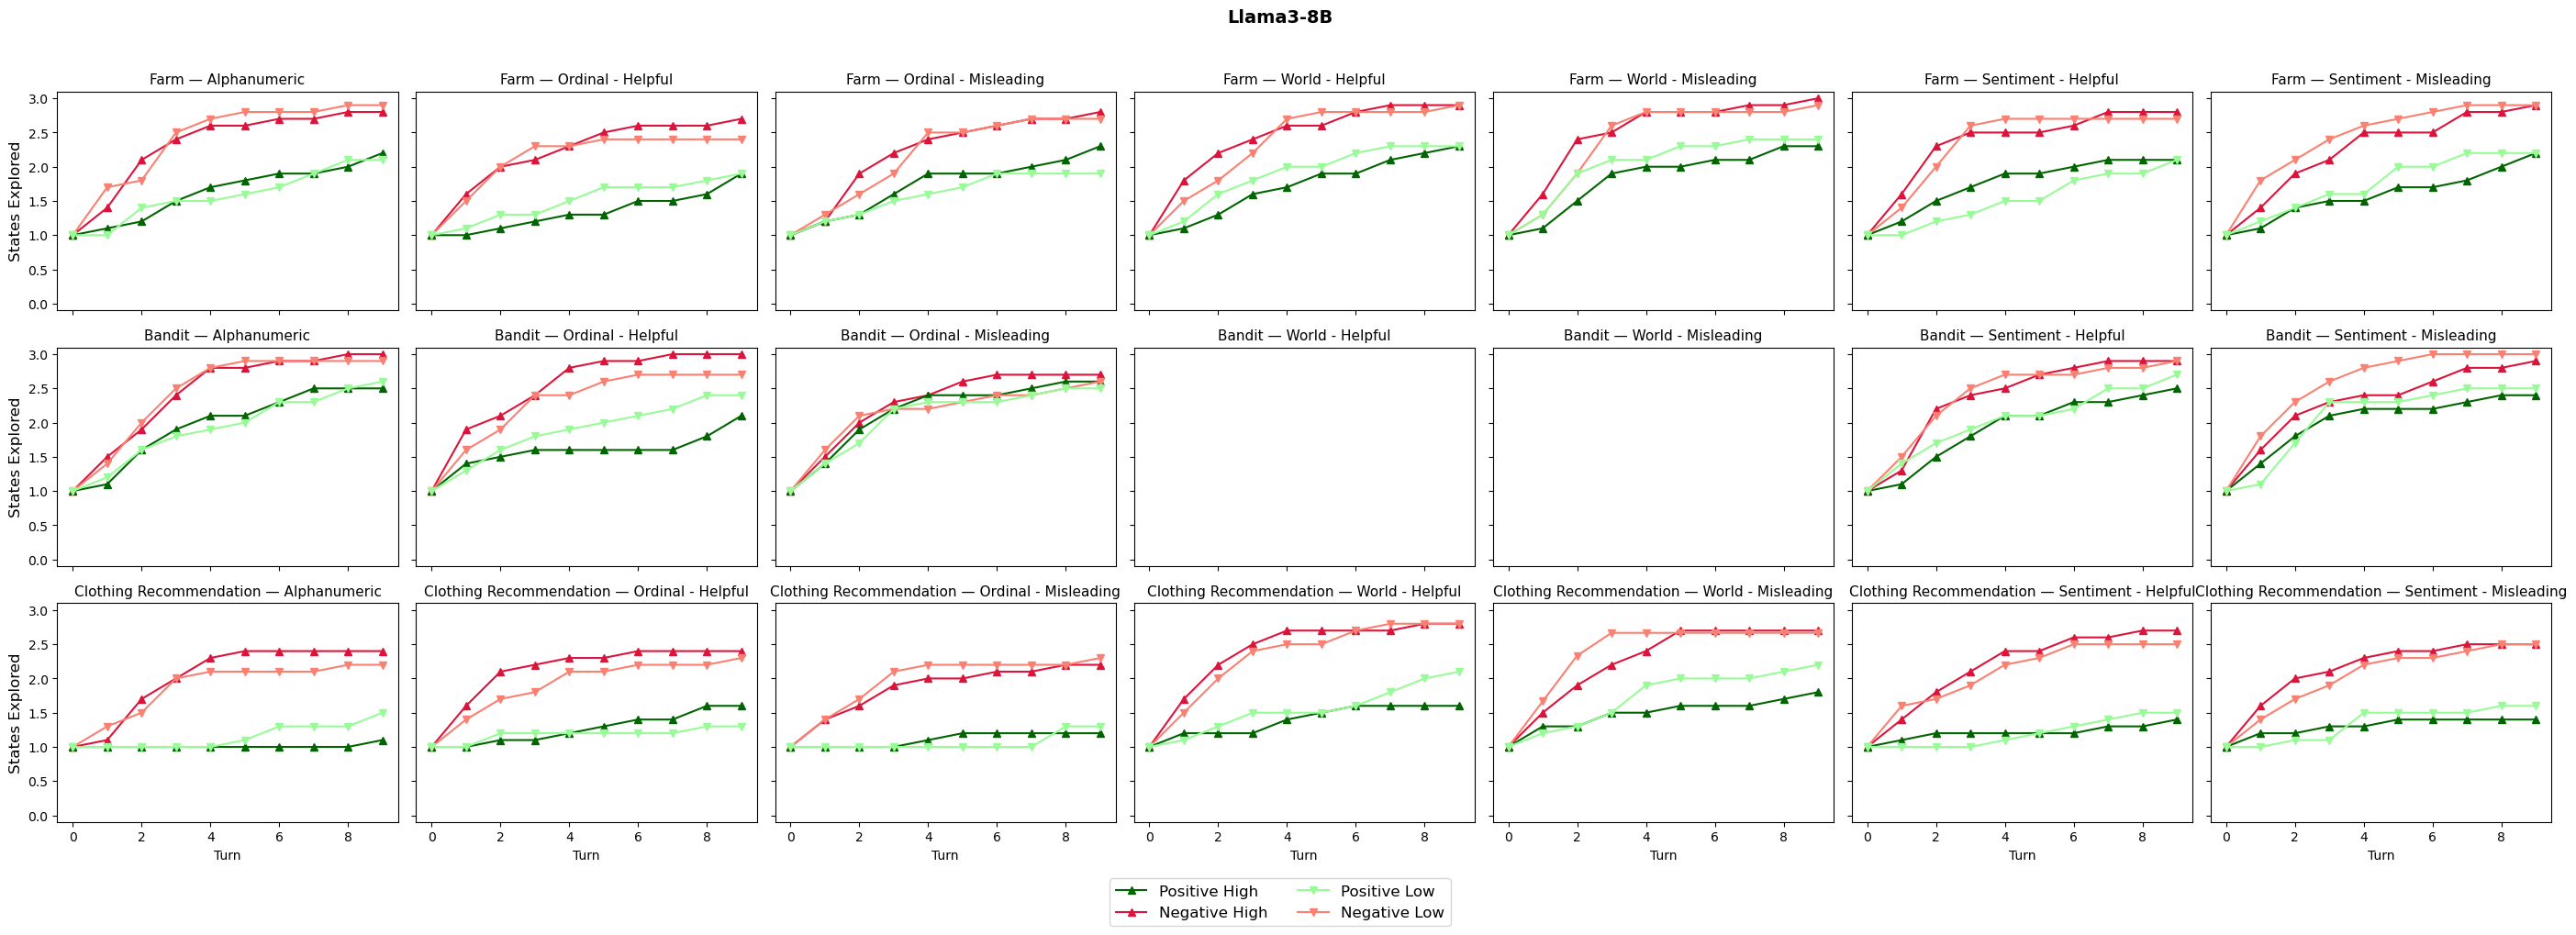

Saved figures for model=Llama3-8B, metric=exploration_count


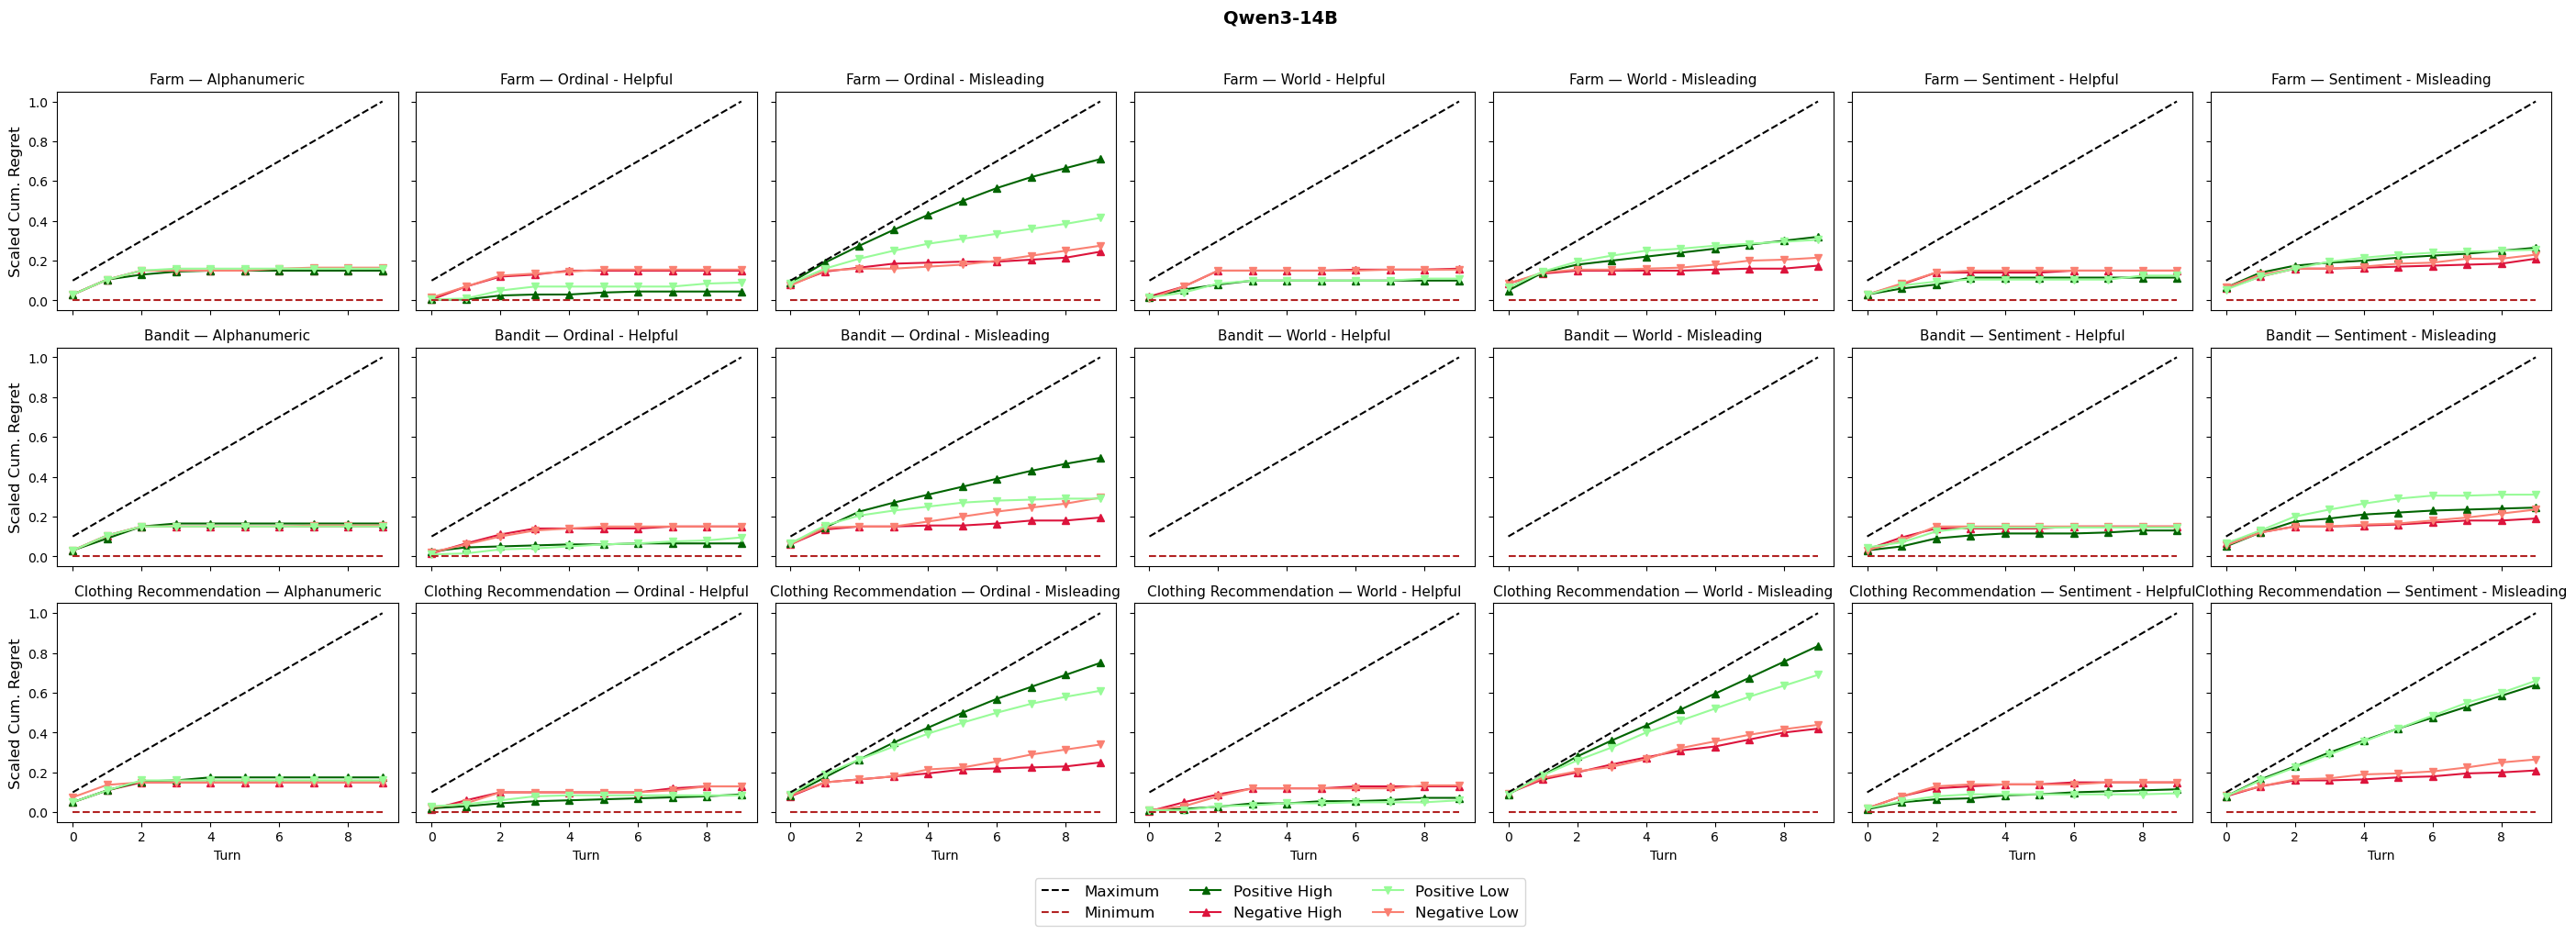

Saved figures for model=Qwen3-14B, metric=cum_regret


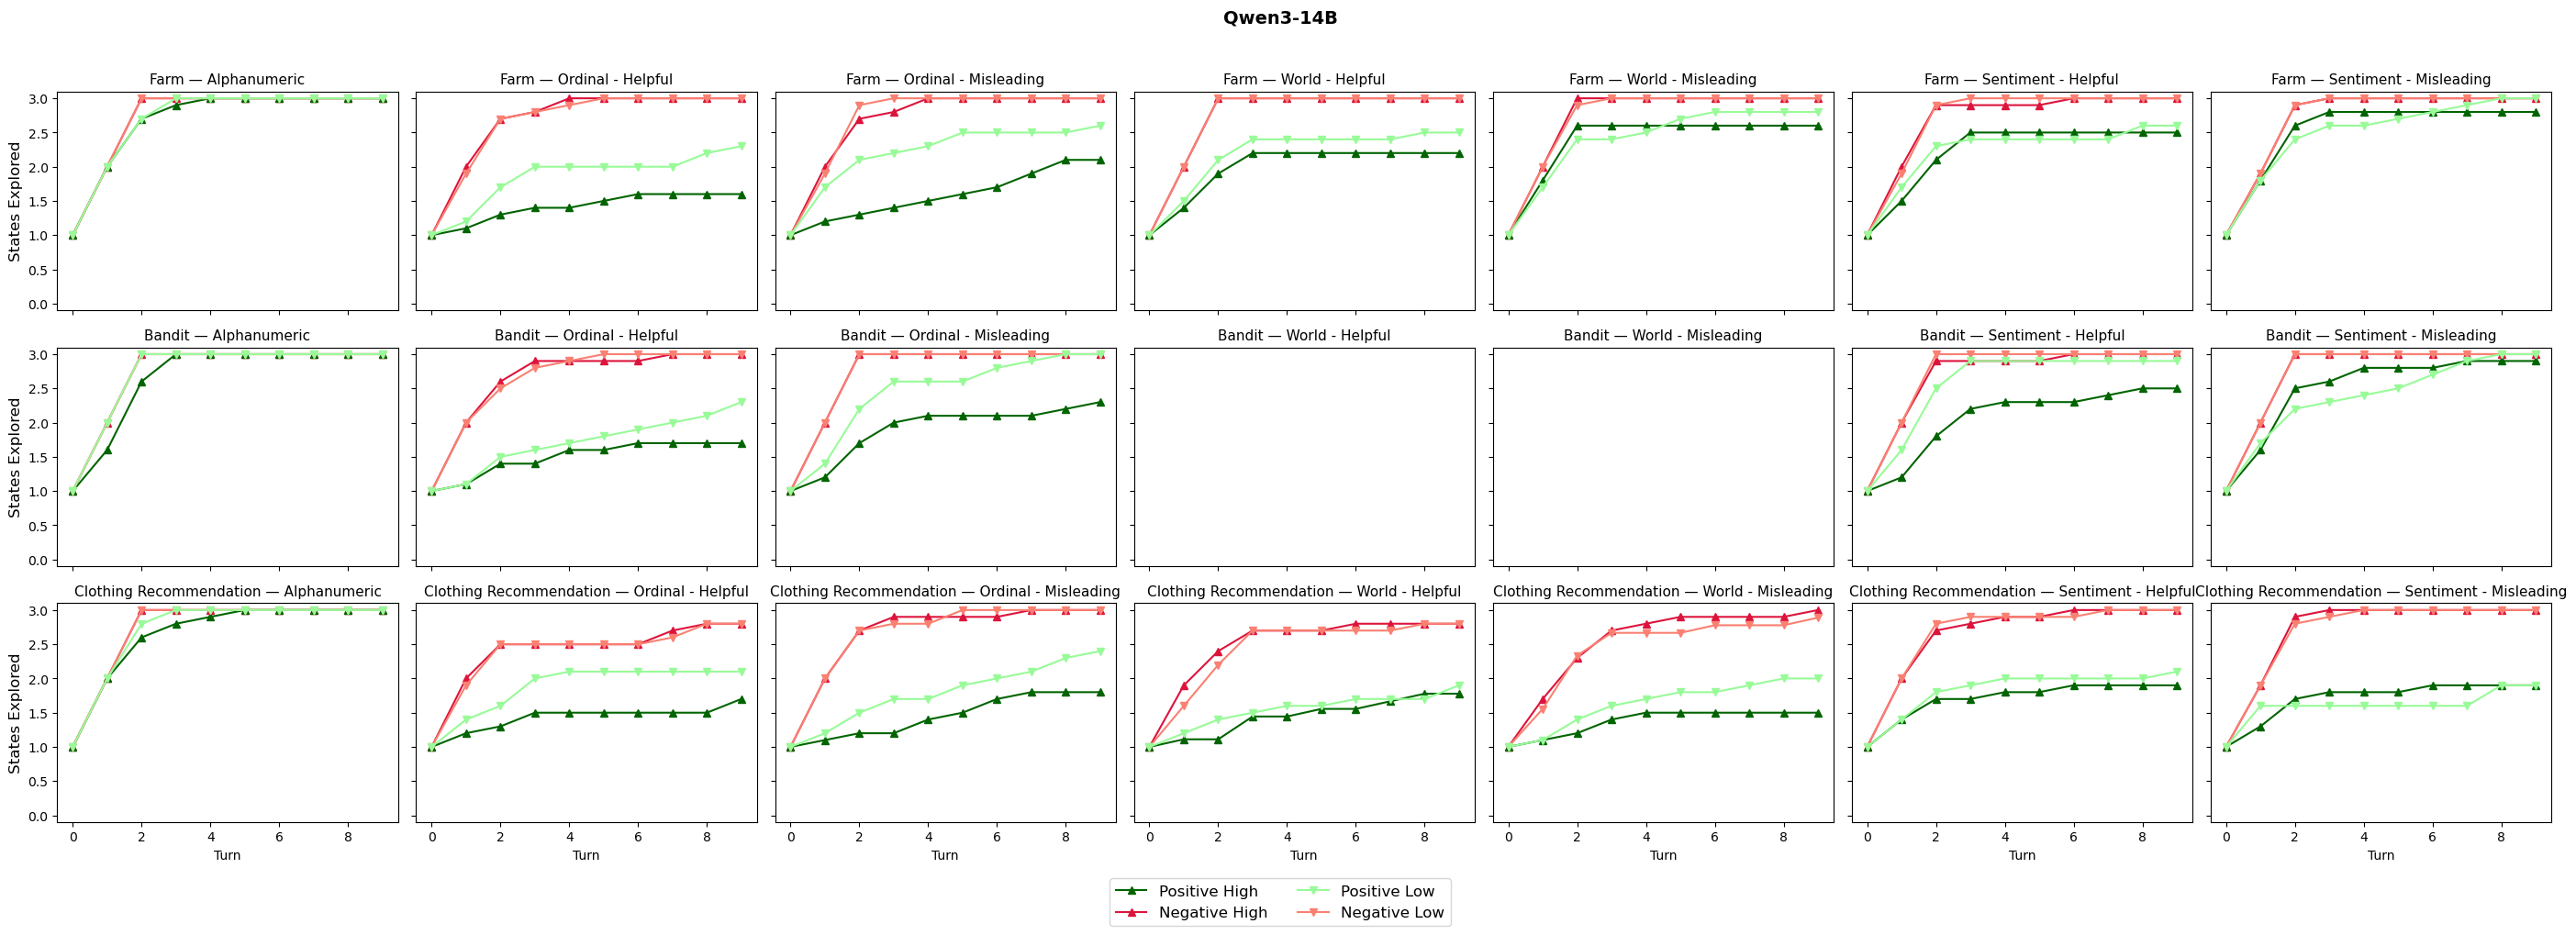

Saved figures for model=Qwen3-14B, metric=exploration_count


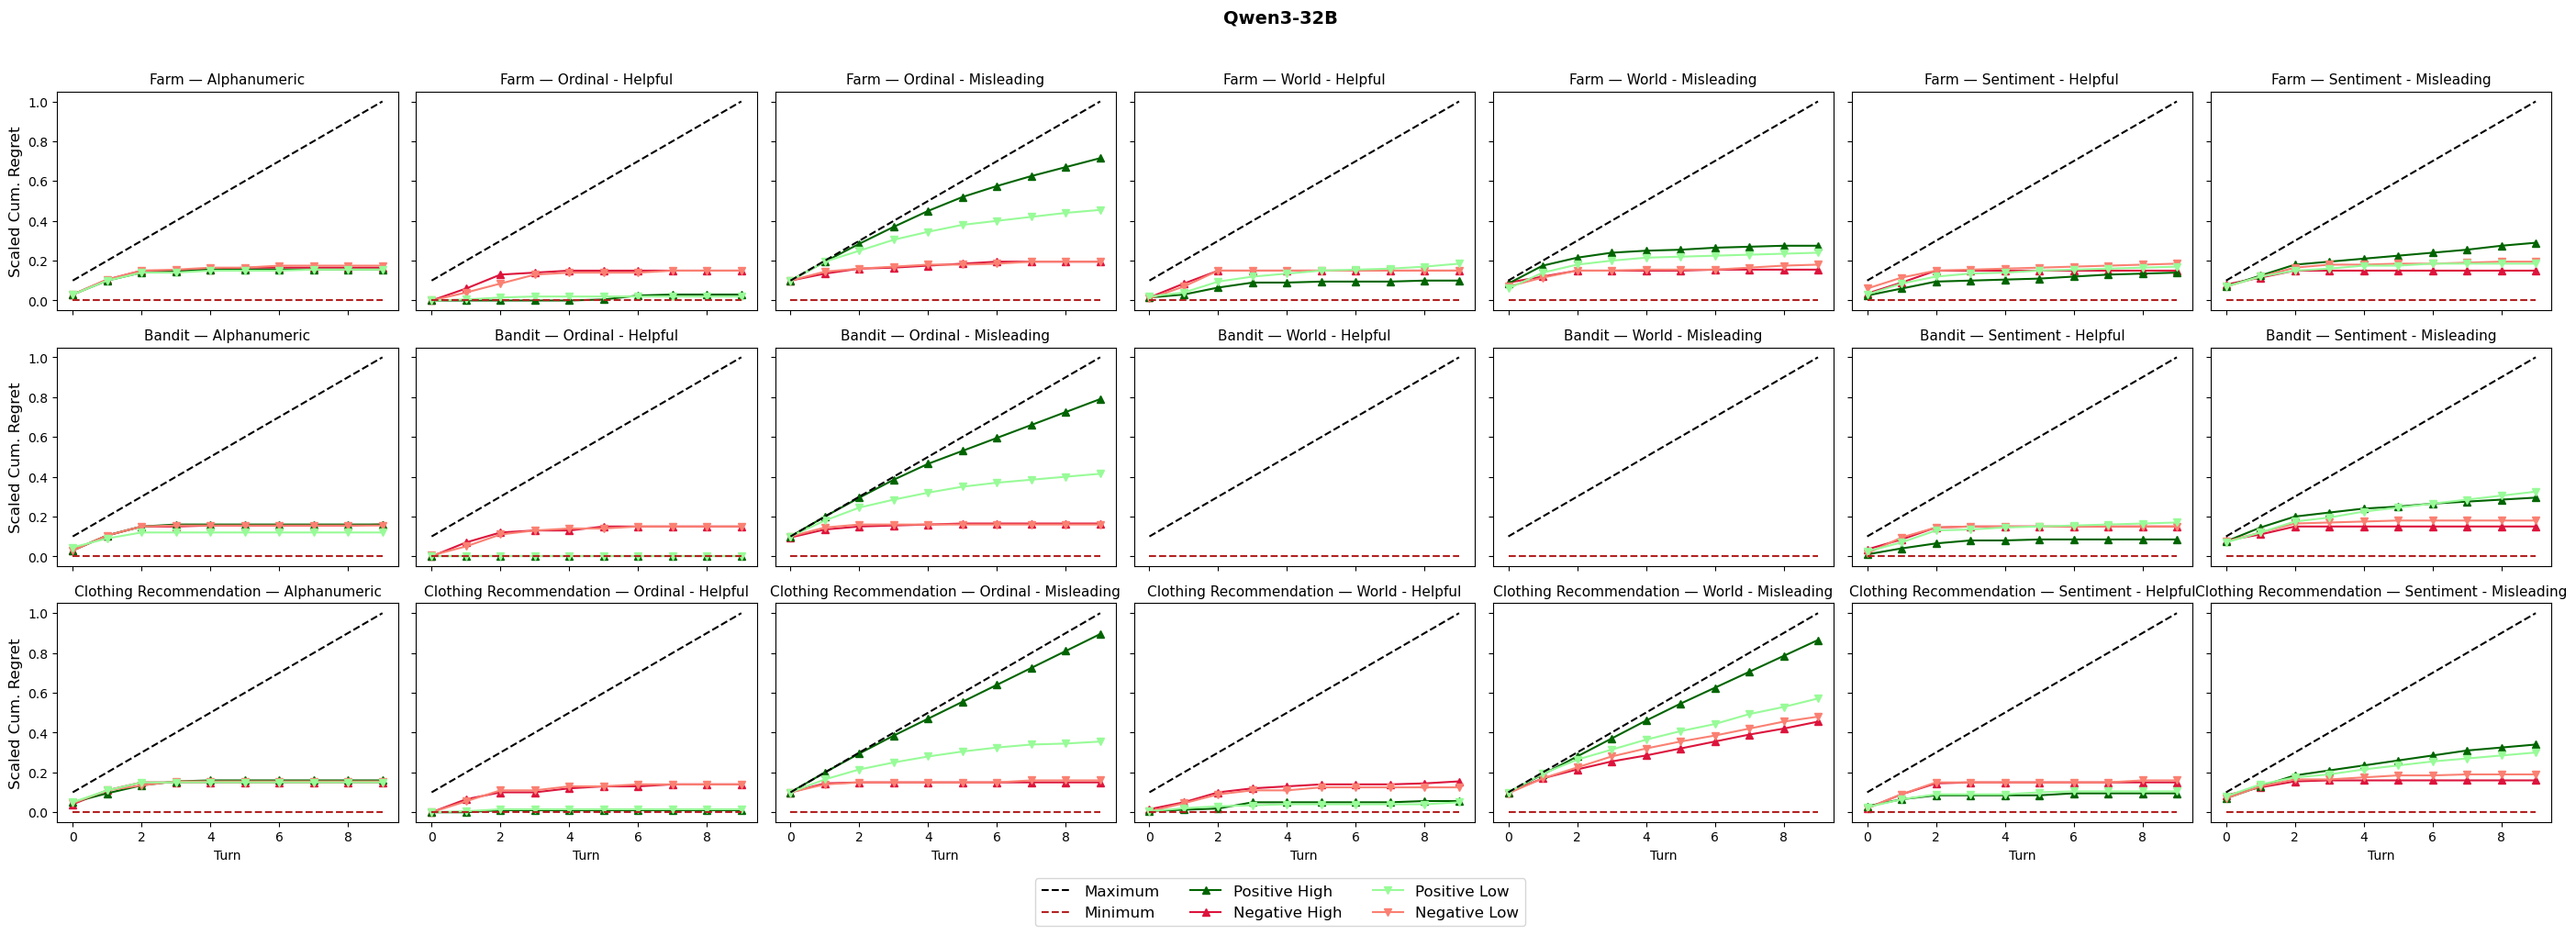

Saved figures for model=Qwen3-32B, metric=cum_regret


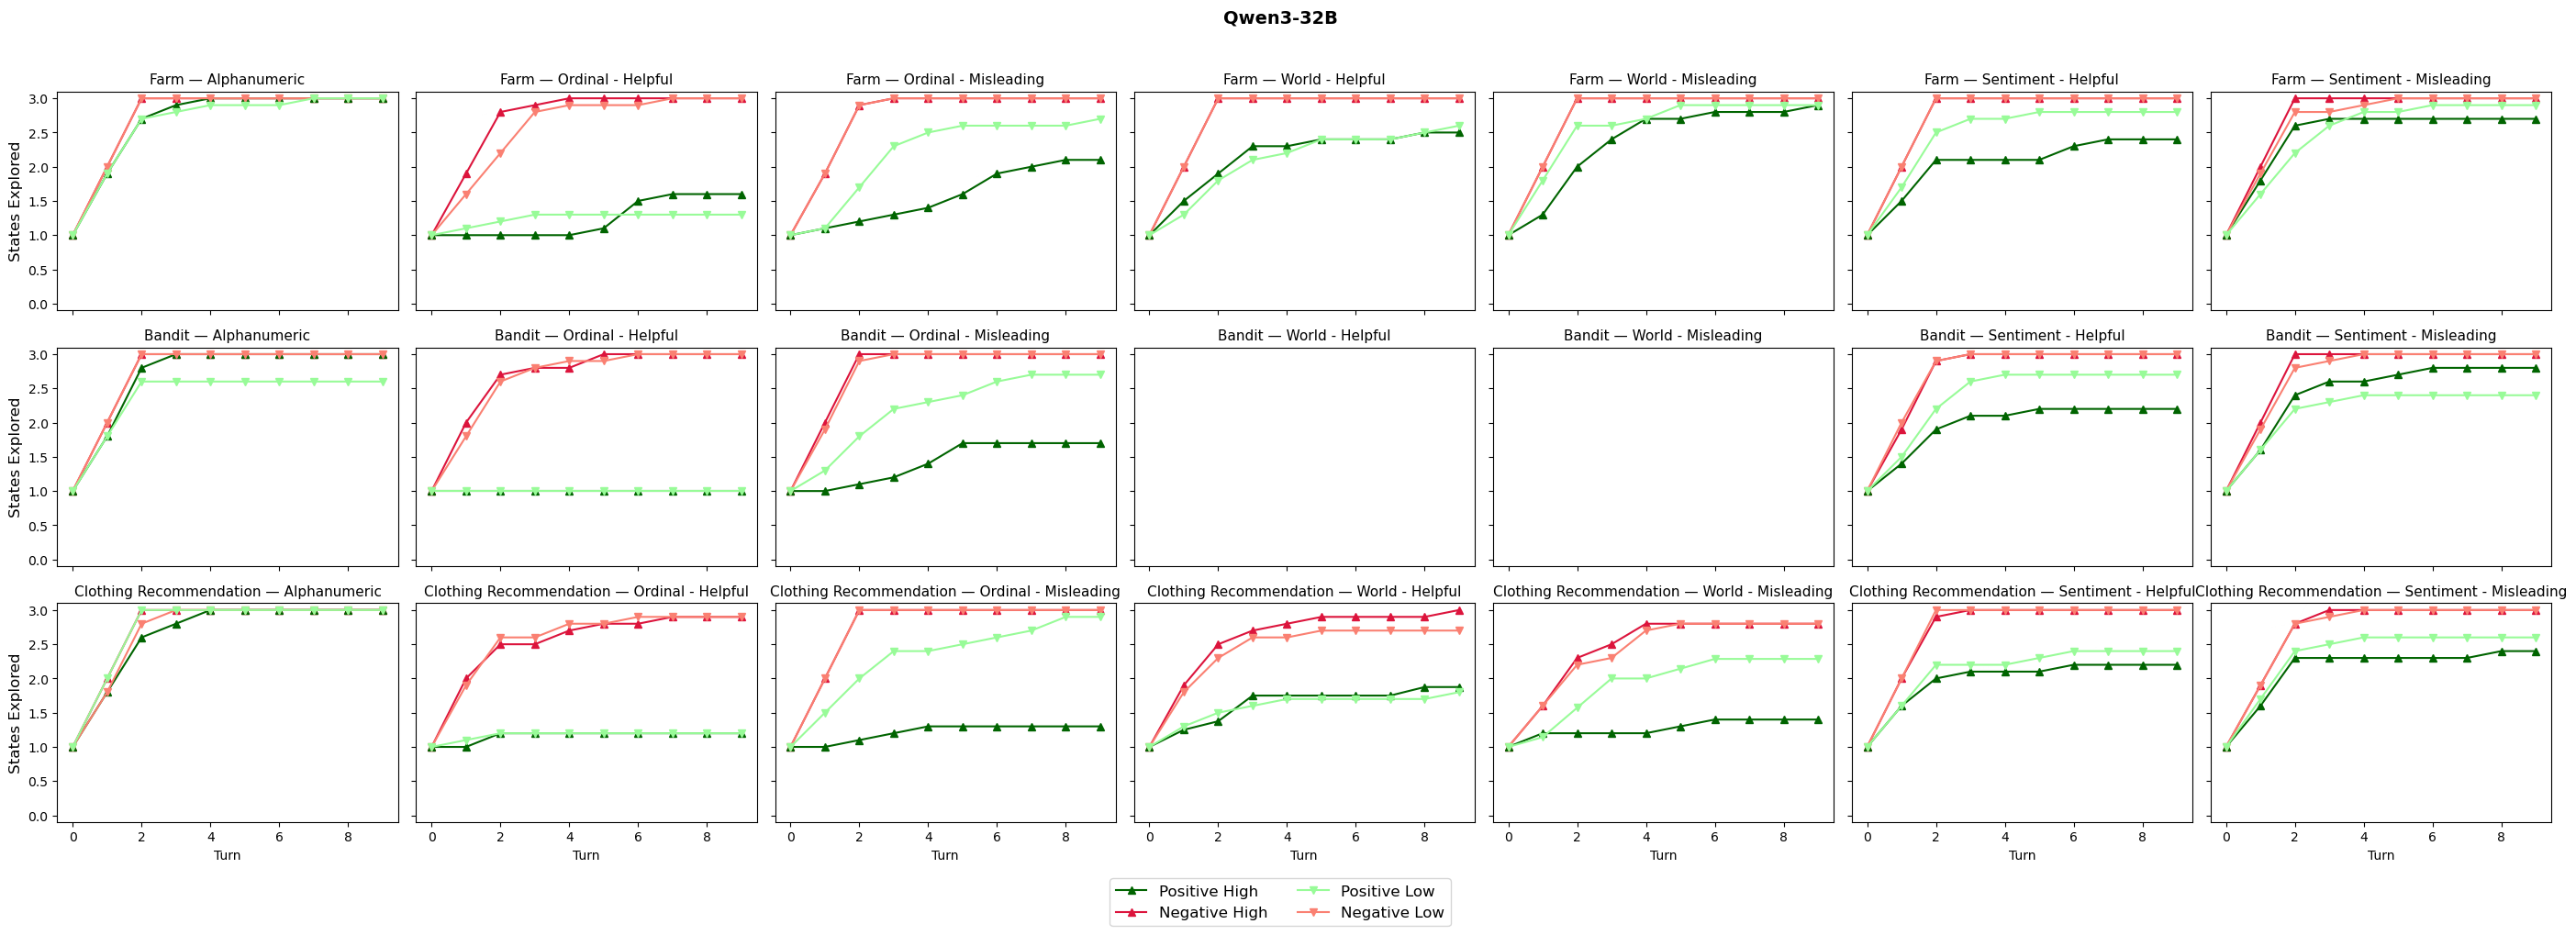

Saved figures for model=Qwen3-32B, metric=exploration_count


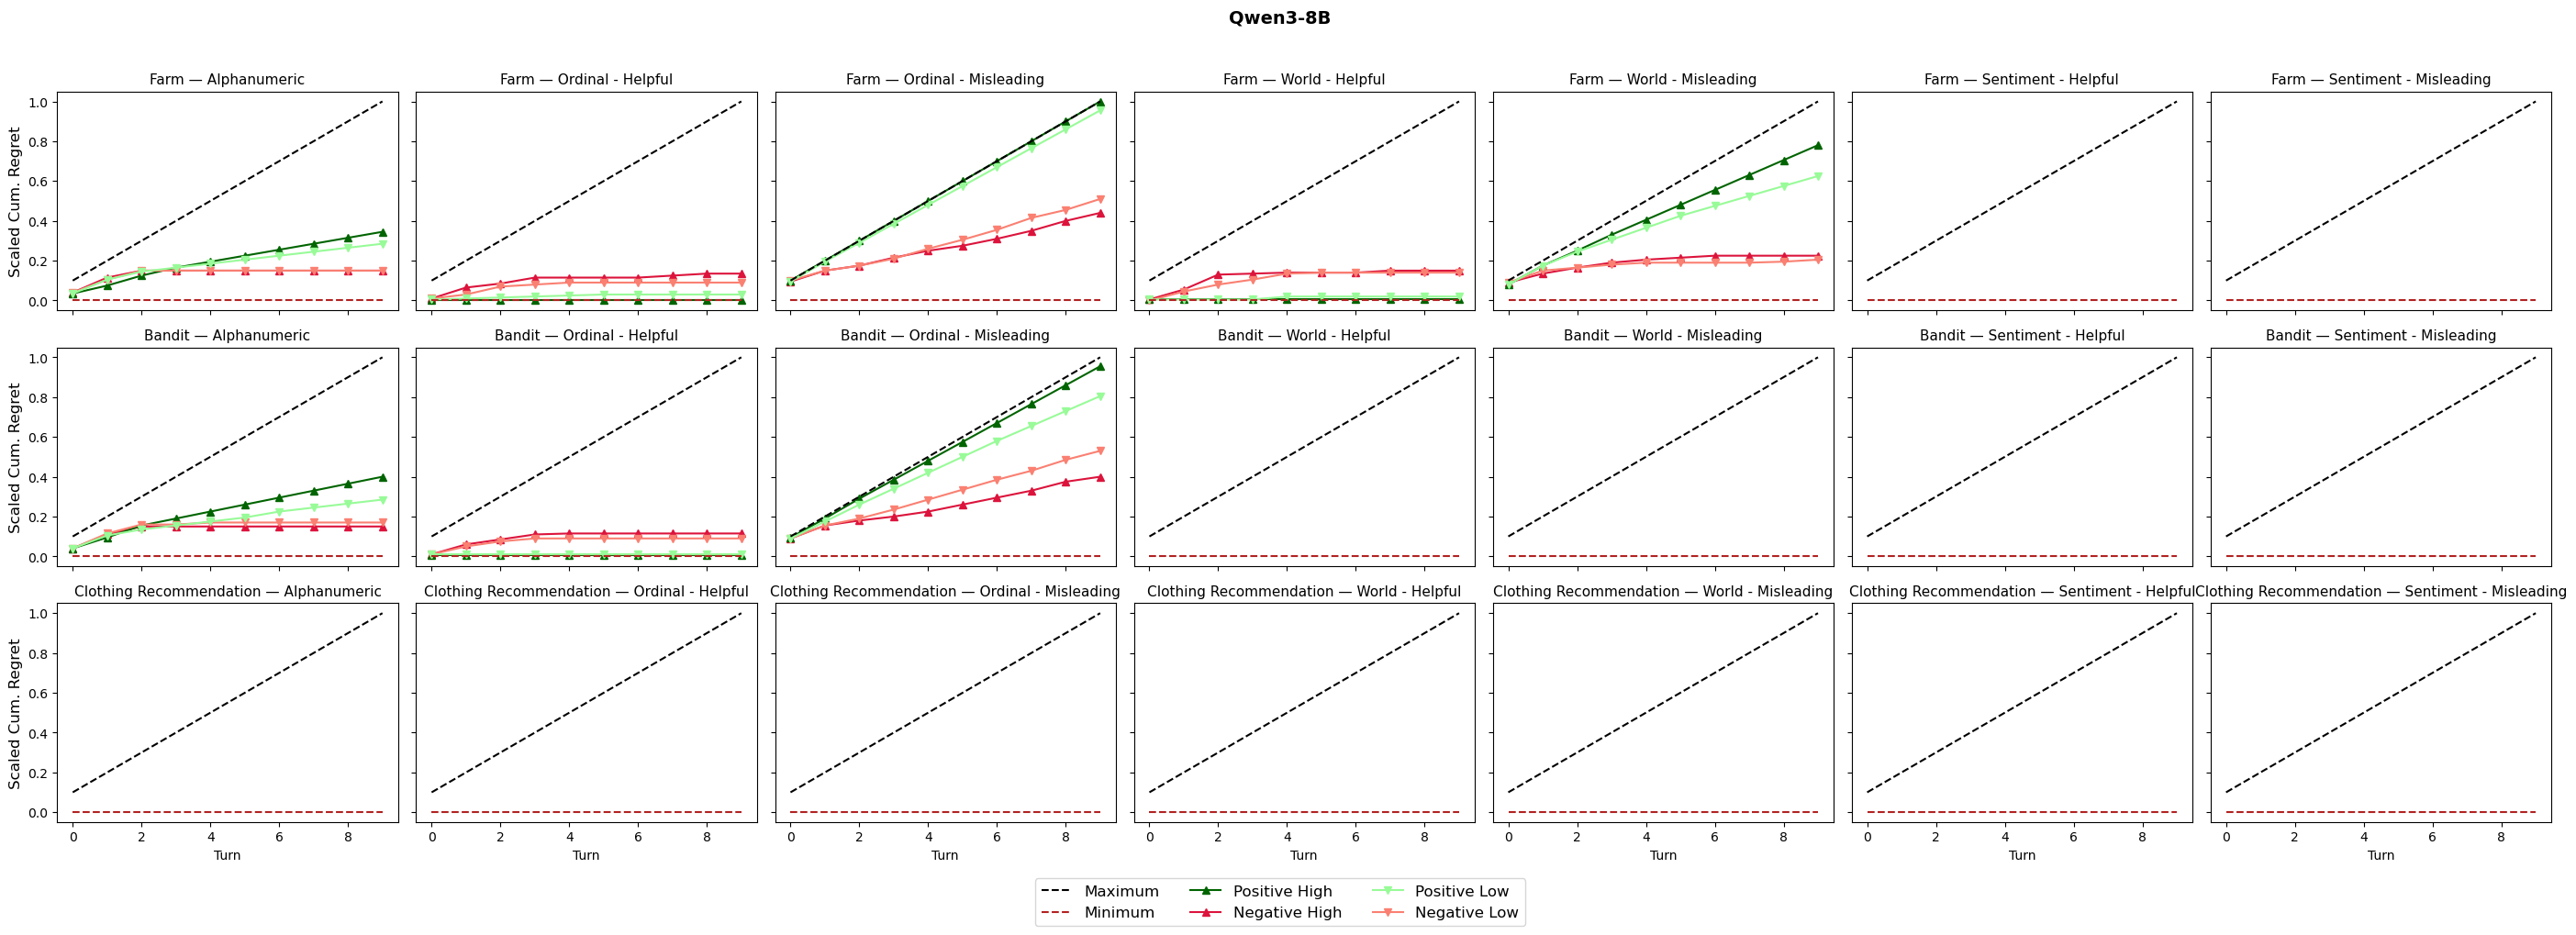

Saved figures for model=Qwen3-8B, metric=cum_regret


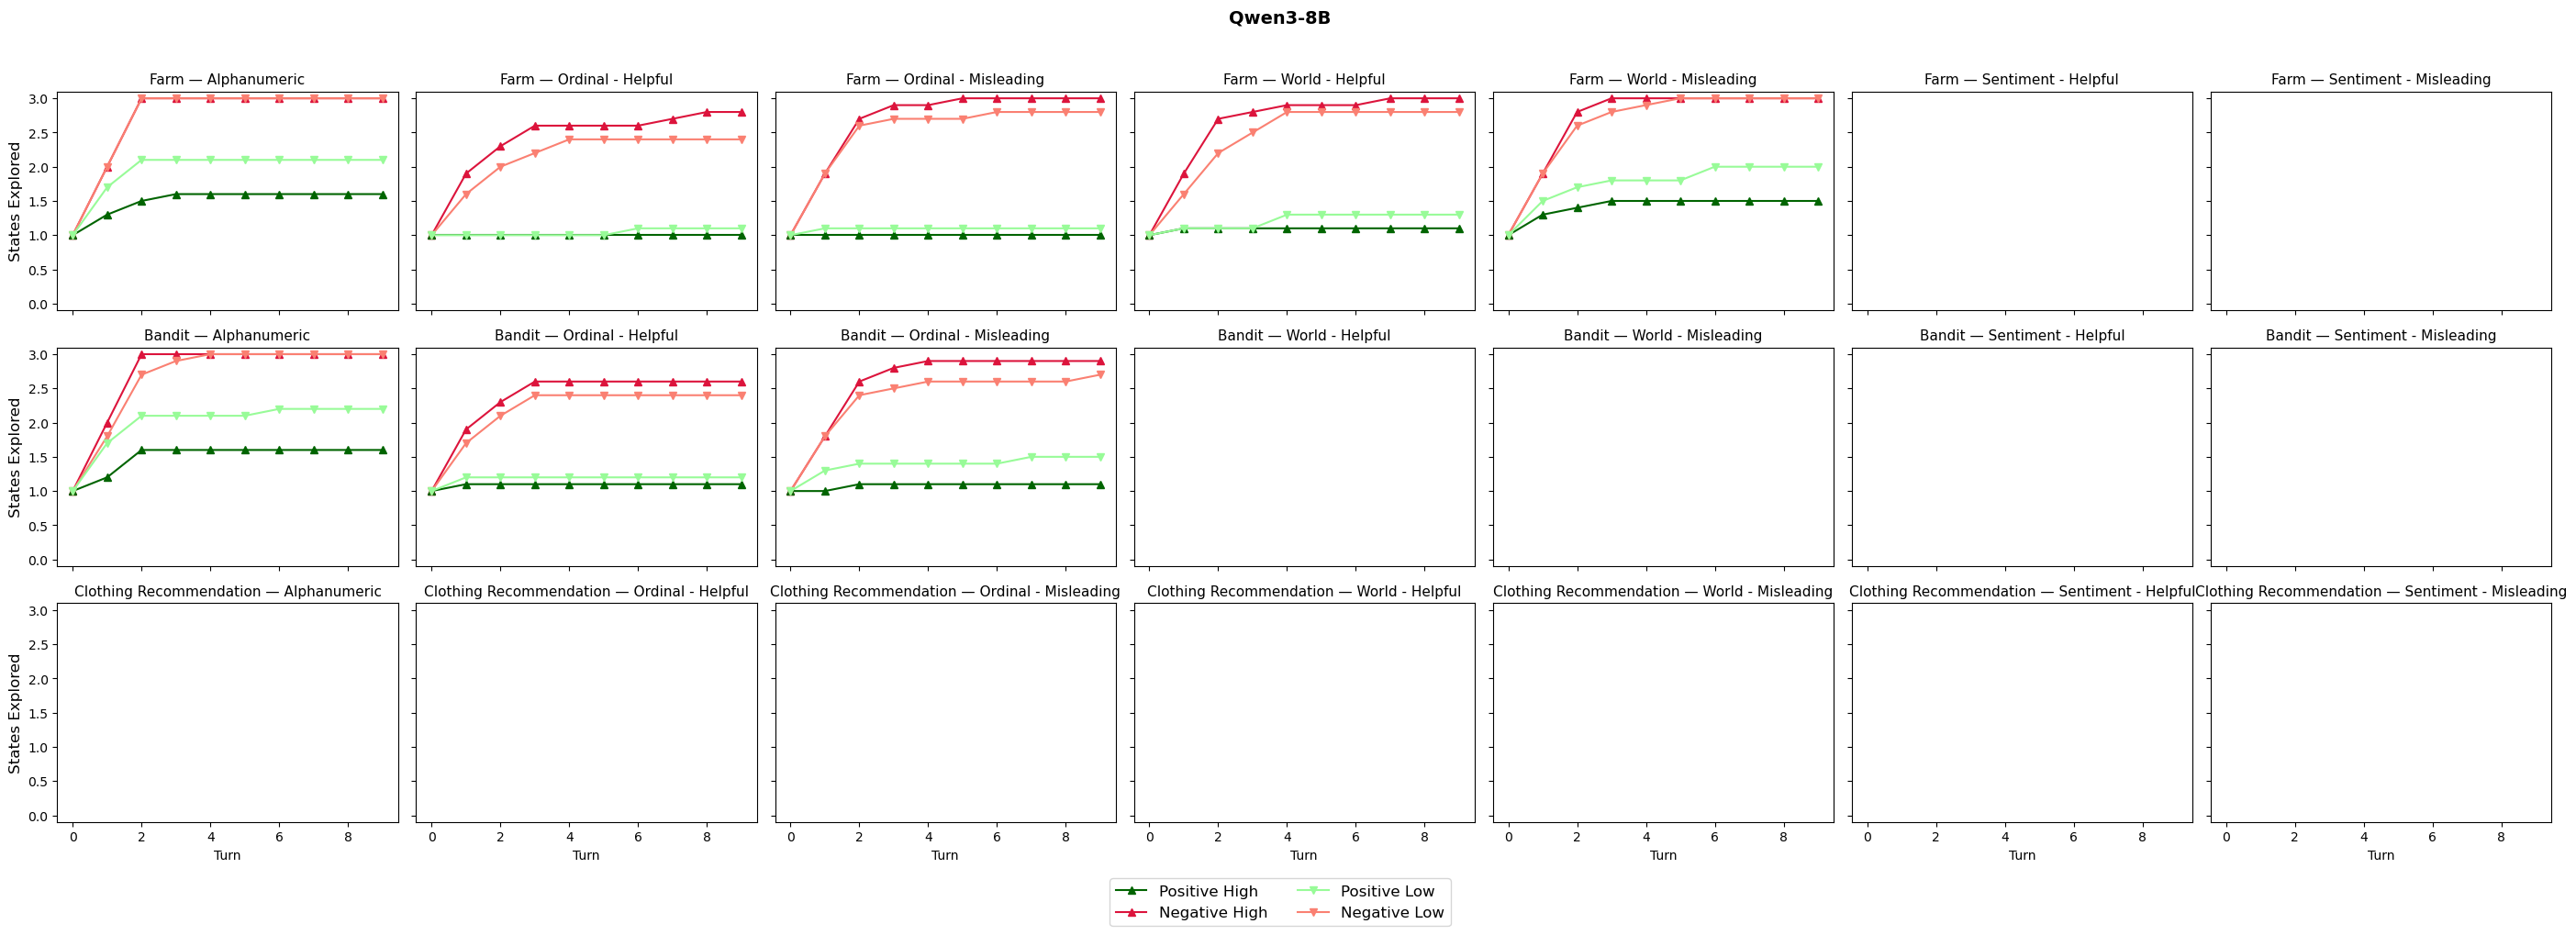

Saved figures for model=Qwen3-8B, metric=exploration_count


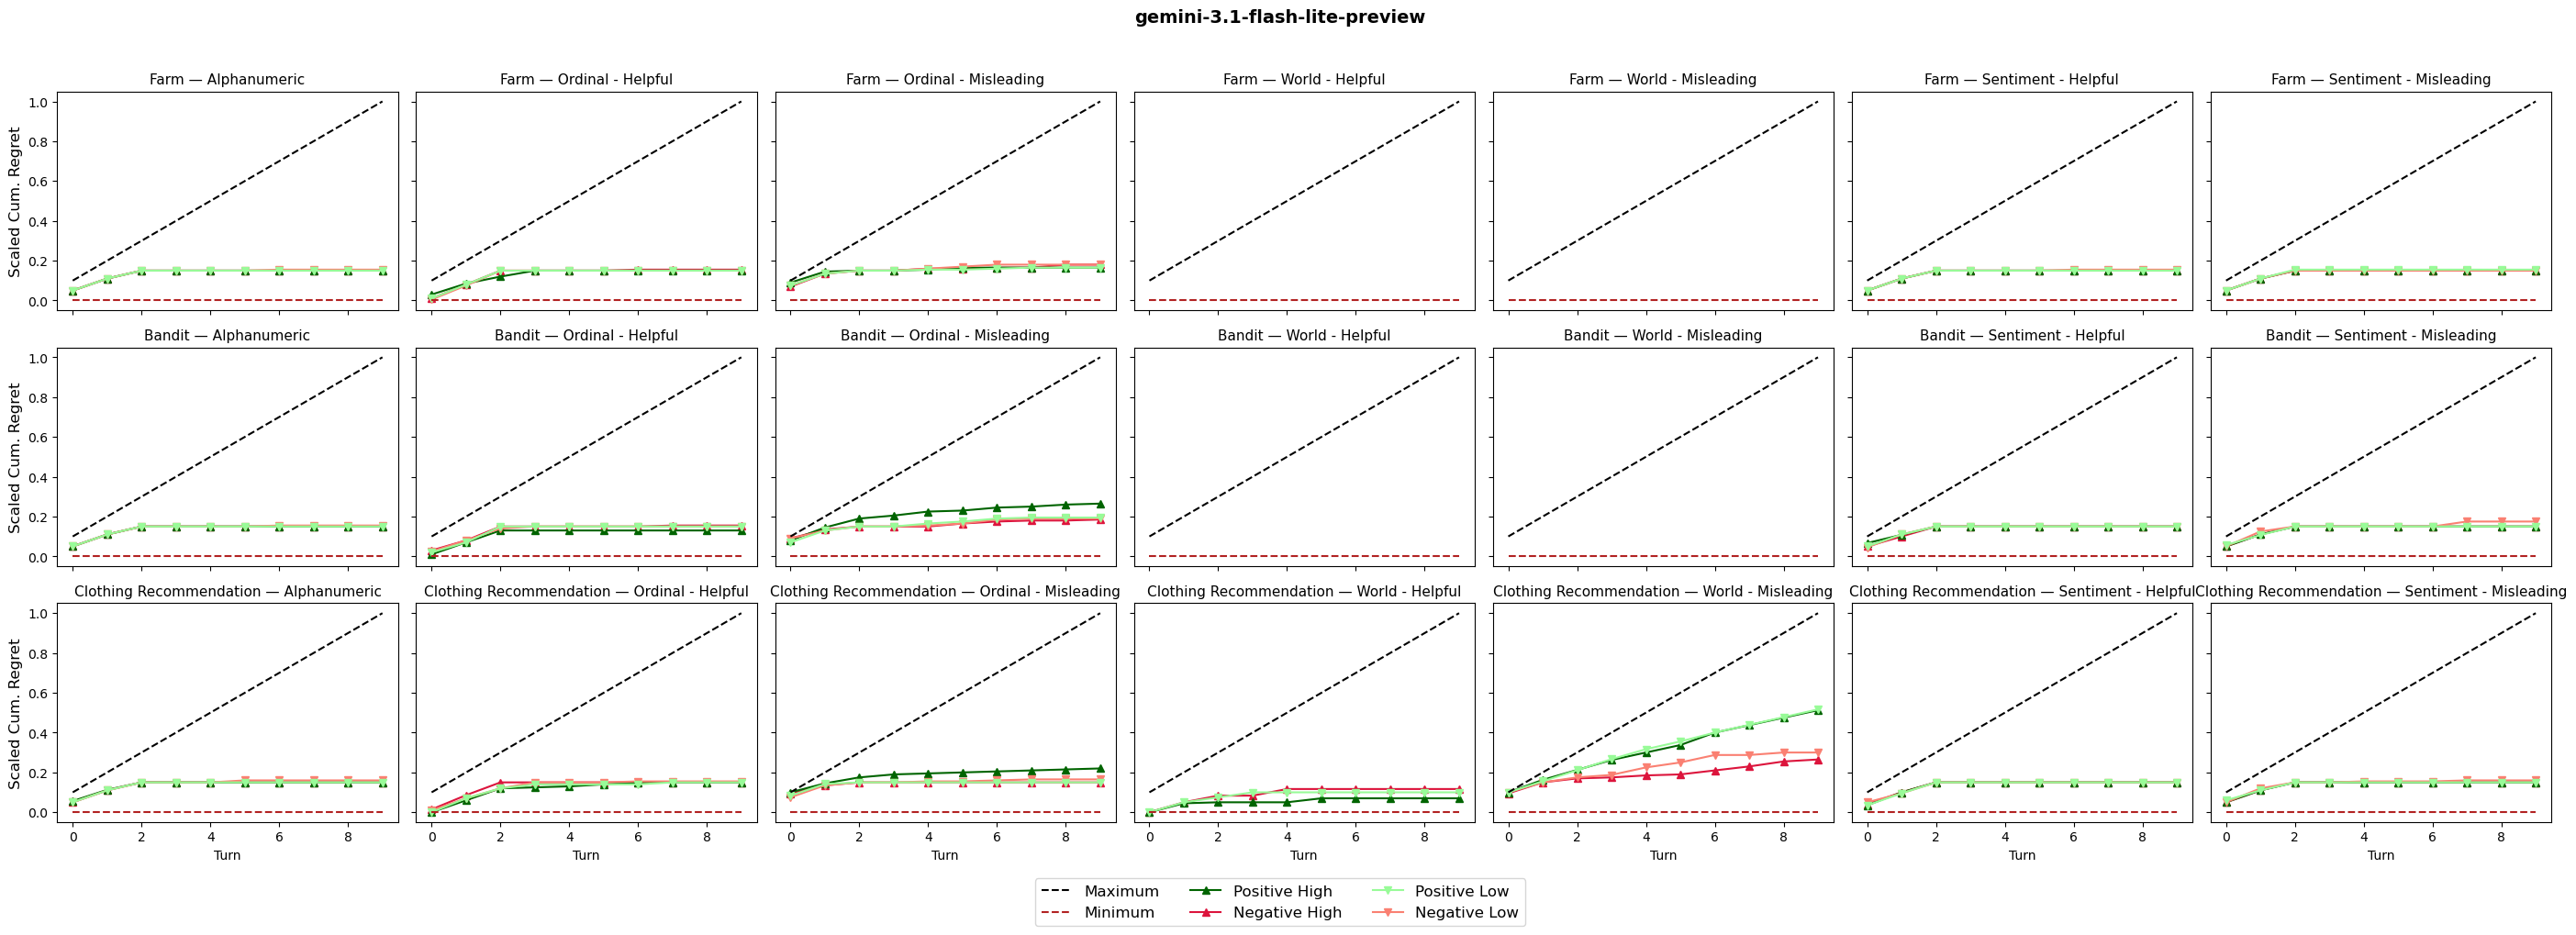

Saved figures for model=gemini-3.1-flash-lite-preview, metric=cum_regret


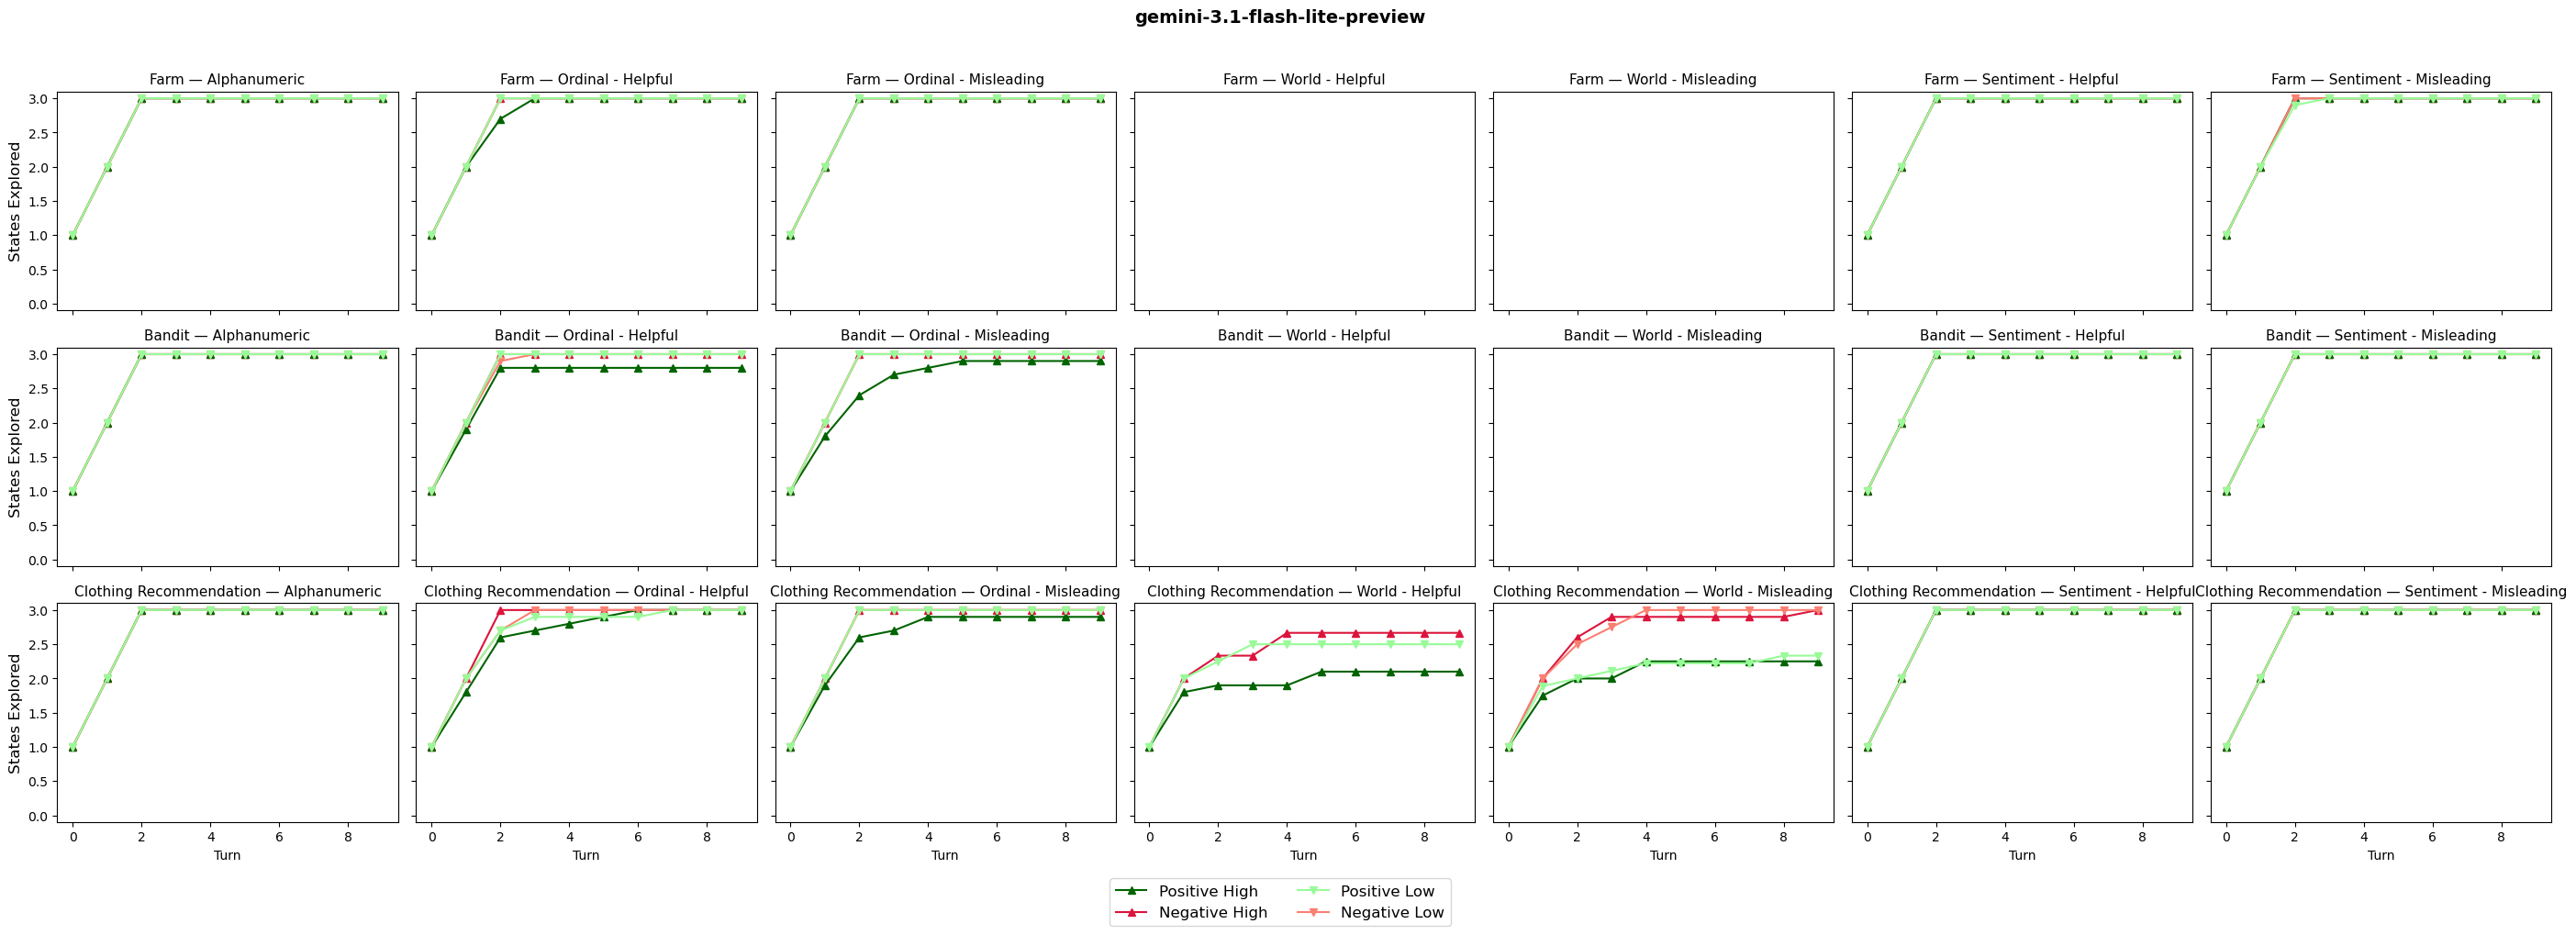

Saved figures for model=gemini-3.1-flash-lite-preview, metric=exploration_count


In [6]:
all_models = sorted(results_df['model'].unique())

# Ordered domain list, restricted to those present in the data
present_domains = results_df['domain'].unique()
domains = [d for d in domain_order if d in present_domains] + \
          [d for d in present_domains if d not in domain_order]

for model in all_models:
    model_safe = re.sub(r'[^\w\-]', '_', model)
    subset = results_df[
        (results_df['model'] == model) &
        (results_df['history'] == hist) &
        (results_df['variance'] == variance)
    ]
    if subset.empty:
        print(f"No data for model={model}, history={hist}, variance={variance} — skipping.")
        continue

    for metric_name in metrics:
        fig, axes = plt.subplots(
            len(domains), len(nomenclatures),
            figsize=(4 * len(nomenclatures), 3.5 * len(domains)),
            sharex=True, sharey=True
        )
        # Normalise axes to always be 2-D
        if len(domains) == 1:
            axes = axes[np.newaxis, :]

        fig.suptitle(f"{model}", fontsize=14, fontweight='bold')

        label_to_handle = {}

        for row_idx, domain in enumerate(domains):
            domain_subset = subset[subset['domain'] == domain]

            for col_idx, subplot_kwd in enumerate(nomenclatures):
                ax = axes[row_idx, col_idx]
                filtered_df = domain_subset[
                    domain_subset['nomenclature'].str.contains(subplot_kwd, na=False)
                ].copy()

                turn_numbers = sorted(
                    int(col.split('_')[-2])
                    for col in domain_subset.columns
                    if col.startswith(f"{metric_name}_") and col.endswith("_mean")
                )

                for scale_key in filtered_df['scale'].unique():
                    scale_df = filtered_df[filtered_df['scale'] == scale_key]
                    means = scale_df[[f"{metric_name}_{t}_mean" for t in turn_numbers]].values.flatten()

                    if metric_name == 'cum_regret':
                        normalizing_constant = (
                            max(rewards_per_scale[scale_key]) - min(rewards_per_scale[scale_key])
                        ) * len(means)
                        means = [x / normalizing_constant for x in means]

                    try:
                        handle, = ax.plot(turn_numbers, means, **STYLE_CONSTANTS[scale_key])
                        label = STYLE_CONSTANTS[scale_key]['label']
                        if label not in label_to_handle:
                            label_to_handle[label] = handle
                    except Exception as e:
                        print(f"ERROR: model={model} domain={domain} scale={scale_key} nom={subplot_kwd}: {e}")

                # Upper and lower bounds for cum_regret
                if metric_name == 'cum_regret' and len(turn_numbers) > 0:
                    max_step = 1.0 / len(turn_numbers)
                    bounds = {
                        'max_val': list(np.linspace(max_step, 1.0, len(turn_numbers))),
                        'min_val': [0.0] * len(turn_numbers),
                    }
                    for bound_key, bound_vals in bounds.items():
                        handle, = ax.plot(turn_numbers, bound_vals, **STYLE_CONSTANTS[bound_key])
                        label = STYLE_CONSTANTS[bound_key]['label']
                        if label not in label_to_handle:
                            label_to_handle[label] = handle

                # Axis label visibility
                if col_idx == 0:
                    ax.set_ylabel(metric_map[metric_name], fontsize=12)
                    ax.yaxis.set_tick_params(labelleft=True)
                else:
                    ax.set_ylabel("")
                    ax.yaxis.set_tick_params(labelleft=False)

                if row_idx == len(domains) - 1:
                    ax.set_xlabel("Turn")
                    ax.xaxis.set_tick_params(labelbottom=True)
                else:
                    ax.set_xlabel("")
                    ax.xaxis.set_tick_params(labelbottom=False)

                if metric_name == 'exploration_count':
                    ax.set_ylim(-0.1, 3.1)

                nom_display = nomenclature_map.get(subplot_kwd, subplot_kwd)
                ax.set_title(f"{domain} — {nom_display}", fontsize=11)

        # Shared legend
        sorted_labels  = [STYLE_CONSTANTS[k]['label'] for k in legend_order if STYLE_CONSTANTS[k]['label'] in label_to_handle]
        sorted_handles = [label_to_handle[lbl] for lbl in sorted_labels]
        ncols = 3 if metric_name == 'cum_regret' else 2
        fig.legend(
            sorted_handles, sorted_labels,
            loc='lower center', bbox_to_anchor=(0.5, 0.02),
            ncol=ncols, borderaxespad=0.5, frameon=True, fontsize=12
        )
        plt.tight_layout(rect=[0, 0.08, 1, 0.96])

        os.makedirs(f"figures/{metric_name}/{model_safe}", exist_ok=True)
        plt.savefig(f"figures/{metric_name}/{model_safe}/main_figure.pdf", dpi=300, bbox_inches='tight')

        os.makedirs(f"figures_png/{metric_name}/{model_safe}", exist_ok=True)
        plt.savefig(f"figures_png/{metric_name}/{model_safe}/main_figure.png", dpi=300, bbox_inches='tight')

        plt.show()
        print(f"Saved figures for model={model}, metric={metric_name}")